In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [96]:
df = pd.read_csv("clean-dataset/unified_dataset_without_normalised.csv")

In [98]:
df.head(10)

,date,Hour,Junction,Vehicles,DayOfWeek,Month,Weekend,Vehicles_Lag1,Vehicles_Lag24,temperature,dew_point,specific humidity,relative_humidity,precipitation,wind_speed,holiday
0,2015-01-11,0,1,0.078212,6,1,1,0.078212,0.078212,7.33,-3.56,2.92,45.45,0.0,3.61,0
1,2015-01-11,0,2,0.027933,6,1,1,0.078212,0.078212,7.33,-3.56,2.92,45.45,0.0,3.61,0
2,2015-01-11,0,3,0.044693,6,1,1,0.078212,0.078212,7.33,-3.56,2.92,45.45,0.0,3.61,0
3,2015-01-11,1,1,0.067039,6,1,1,0.078212,0.078212,6.59,-3.77,2.88,47.15,0.0,3.57,0
4,2015-01-11,1,2,0.027933,6,1,1,0.027933,0.078212,6.59,-3.77,2.88,47.15,0.0,3.57,0
5,2015-01-11,1,3,0.033520,6,1,1,0.044693,0.078212,6.59,-3.77,2.88,47.15,0.0,3.57,0
6,2015-01-11,2,1,0.050279,6,1,1,0.067039,0.078212,5.91,-3.90,2.85,48.88,0.0,3.46,0
7,2015-01-11,2,2,0.022346,6,1,1,0.027933,0.078212,5.91,-3.90,2.85,48.88,0.0,3.46,0
8,2015-01-11,2,3,0.022346,6,1,1,0.033520,0.078212,5.91,-3.90,2.85,48.88,0.0,3.46,0
9,2015-01-11,3,1,0.033520,6,1,1,0.050279,0.078212,5.32,-4.02,2.82,50.36,0.0,3.38,0


In [100]:
df.head()

,date,Hour,Junction,Vehicles,DayOfWeek,Month,Weekend,Vehicles_Lag1,Vehicles_Lag24,temperature,dew_point,specific humidity,relative_humidity,precipitation,wind_speed,holiday
0,2015-01-11,0,1,0.078212,6,1,1,0.078212,0.078212,7.33,-3.56,2.92,45.45,0.0,3.61,0
1,2015-01-11,0,2,0.027933,6,1,1,0.078212,0.078212,7.33,-3.56,2.92,45.45,0.0,3.61,0
2,2015-01-11,0,3,0.044693,6,1,1,0.078212,0.078212,7.33,-3.56,2.92,45.45,0.0,3.61,0
3,2015-01-11,1,1,0.067039,6,1,1,0.078212,0.078212,6.59,-3.77,2.88,47.15,0.0,3.57,0
4,2015-01-11,1,2,0.027933,6,1,1,0.027933,0.078212,6.59,-3.77,2.88,47.15,0.0,3.57,0


In [102]:
# original min and max values for Vehicles
original_min = 1 
original_max = 180

# Denormalize the Vehicles column
df['Vehicles'] = df['Vehicles'] * (original_max - original_min) + original_min

In [104]:
df.head()

,date,Hour,Junction,Vehicles,DayOfWeek,Month,Weekend,Vehicles_Lag1,Vehicles_Lag24,temperature,dew_point,specific humidity,relative_humidity,precipitation,wind_speed,holiday
0,2015-01-11,0,1,15.0,6,1,1,0.078212,0.078212,7.33,-3.56,2.92,45.45,0.0,3.61,0
1,2015-01-11,0,2,6.0,6,1,1,0.078212,0.078212,7.33,-3.56,2.92,45.45,0.0,3.61,0
2,2015-01-11,0,3,9.0,6,1,1,0.078212,0.078212,7.33,-3.56,2.92,45.45,0.0,3.61,0
3,2015-01-11,1,1,13.0,6,1,1,0.078212,0.078212,6.59,-3.77,2.88,47.15,0.0,3.57,0
4,2015-01-11,1,2,6.0,6,1,1,0.027933,0.078212,6.59,-3.77,2.88,47.15,0.0,3.57,0


In [106]:
# Calculate average vehicle count per hour
avg_vehicle_count = df.groupby('Hour')['Vehicles'].mean().reset_index()
avg_vehicle_count.columns = ['Hour', 'Average_Vehicles']

In [110]:
# Identify peak hours
peak_hours = avg_vehicle_count[avg_vehicle_count['Average_Vehicles'] == avg_vehicle_count['Average_Vehicles'].max()]

In [112]:
peak_hours

,Hour,Average_Vehicles
19,19,29.854863


In [114]:
# Calculate average vehicle count by DayOfWeek
avg_vehicle_by_day = df.groupby('DayOfWeek')['Vehicles'].mean().reset_index()
avg_vehicle_by_day.columns = ['DayOfWeek', 'Average_Vehicles']

In [116]:
avg_vehicle_by_day

,DayOfWeek,Average_Vehicles
0,0,23.904496
1,1,24.853944
2,2,23.999129
3,3,24.315813
4,4,23.270325
5,5,20.061043
6,6,19.211351


In [118]:
# Calculate average vehicle count by Month
avg_vehicle_by_month = df.groupby('Month')['Vehicles'].mean().reset_index()
avg_vehicle_by_month.columns = ['Month', 'Average_Vehicles']

In [120]:
avg_vehicle_by_month

,Month,Average_Vehicles
0,1,20.824121
1,2,23.312155
2,3,22.886307
3,4,23.475260
4,5,23.594640
5,6,25.372830
6,7,22.744241
7,8,22.099932
8,9,24.897569
9,10,24.827236


In [122]:
# Calculate correlation matrix
correlation_matrix = df[['Vehicles', 'temperature', 'dew_point', 'specific humidity', 
                            'relative_humidity', 'precipitation', 'wind_speed', 'holiday']].corr()
correlation_matrix

,Vehicles,temperature,dew_point,specific humidity,relative_humidity,precipitation,wind_speed,holiday
Vehicles,1.000000,0.145642,0.043162,0.034470,-0.069329,-0.003384,0.047807,-0.032179
temperature,0.145642,1.000000,0.512948,0.437238,-0.181653,0.090737,0.109132,0.014065
dew_point,0.043162,0.512948,1.000000,0.966942,0.712973,0.286084,-0.158782,-0.003392
specific humidity,0.034470,0.437238,0.966942,1.000000,0.762567,0.329377,-0.178900,0.003416
relative_humidity,-0.069329,-0.181653,0.712973,0.762567,1.000000,0.276896,-0.232277,-0.010026
precipitation,-0.003384,0.090737,0.286084,0.329377,0.276896,1.000000,-0.037907,-0.011891
wind_speed,0.047807,0.109132,-0.158782,-0.178900,-0.232277,-0.037907,1.000000,-0.030905
holiday,-0.032179,0.014065,-0.003392,0.003416,-0.010026,-0.011891,-0.030905,1.000000


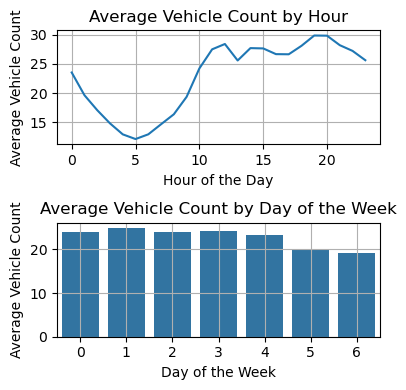

In [174]:
# Create subplots
fig, axs = plt.subplots(2, 1, figsize=(4, 4))

# Plot average vehicle count by hour
sns.lineplot(data=avg_vehicle_count, x='Hour', y='Average_Vehicles', ax=axs[0])
axs[0].set_title('Average Vehicle Count by Hour')
axs[0].set_xlabel('Hour of the Day')
axs[0].set_ylabel('Average Vehicle Count')
axs[0].grid()

# Plot average vehicle count by day of the week
sns.barplot(data=avg_vehicle_by_day, x='DayOfWeek', y='Average_Vehicles', ax=axs[1])
axs[1].set_title('Average Vehicle Count by Day of the Week')
axs[1].set_xlabel('Day of the Week')
axs[1].set_ylabel('Average Vehicle Count')
axs[1].grid()

# Adjust layout
plt.tight_layout()
plt.show()

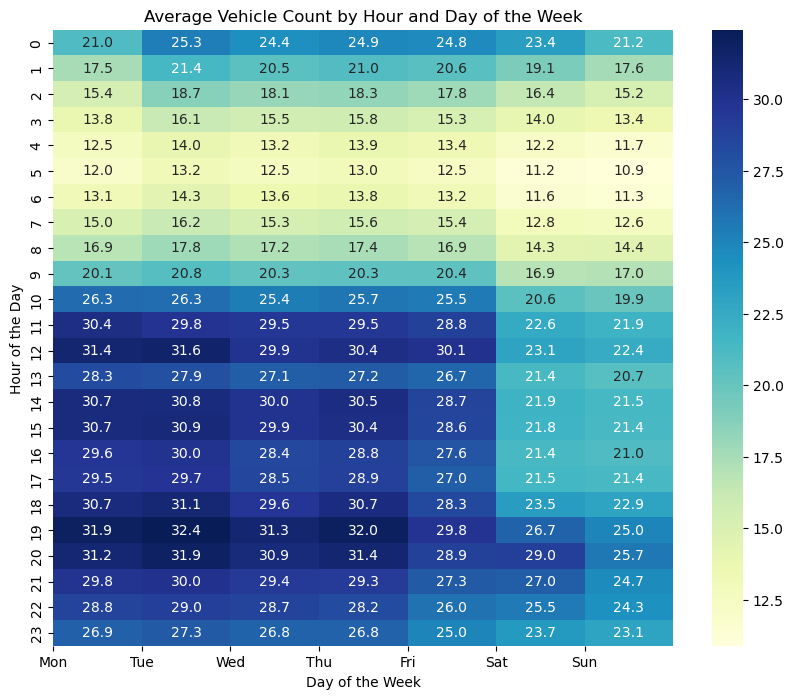

In [178]:
# Visualize Peak Traffic Hours
# Create a pivot table for heatmap
heatmap_data = df.pivot_table(values='Vehicles', index='Hour', columns='DayOfWeek', aggfunc='mean')

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt=".1f")
plt.title('Average Vehicle Count by Hour and Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Hour of the Day')
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.show()

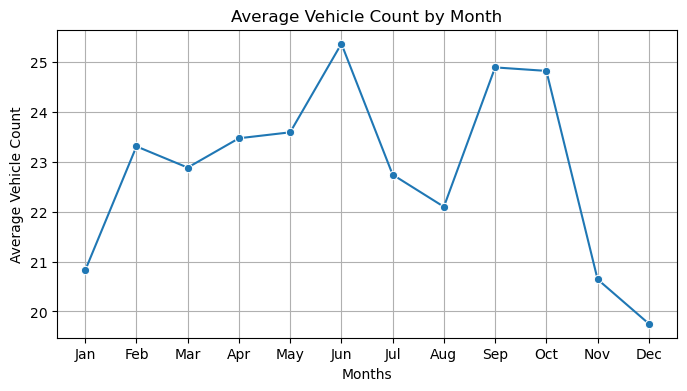

In [182]:
#  Monthly Variations in Peak Traffic
# Calculate average vehicle count by Month
avg_vehicle_by_month = df.groupby('Month')['Vehicles'].mean().reset_index()

# Plot line chart
plt.figure(figsize=(8, 4))
sns.lineplot(data=avg_vehicle_by_month, x='Month', y='Vehicles', marker='o')
plt.title('Average Vehicle Count by Month')
plt.xlabel('Months')
plt.ylabel('Average Vehicle Count')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid()
plt.show()

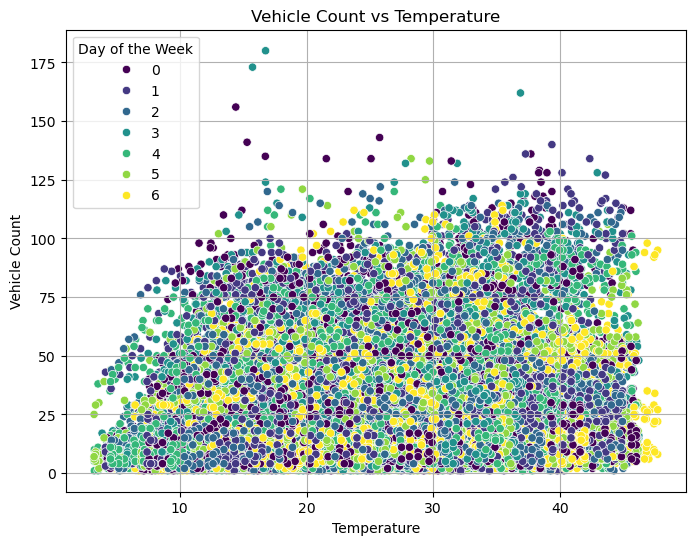

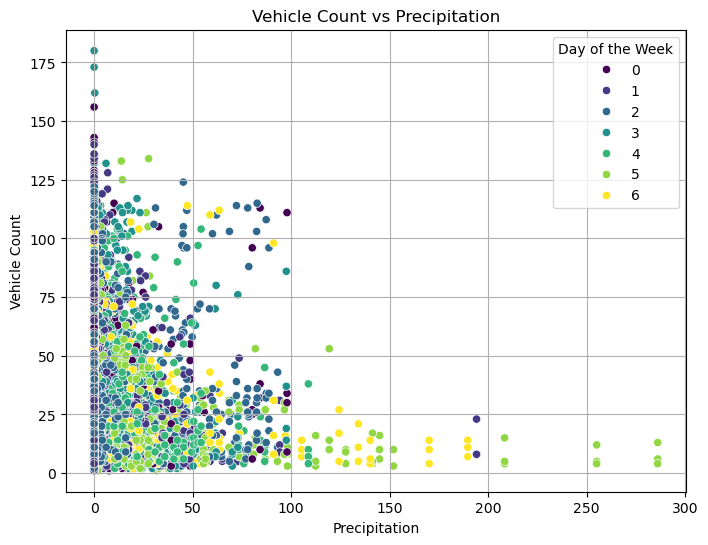

In [184]:
# Scatter plot for Vehicles vs Temperature
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='temperature', y='Vehicles', hue='DayOfWeek', palette='viridis')
plt.title('Vehicle Count vs Temperature')
plt.xlabel('Temperature')
plt.ylabel('Vehicle Count')
plt.legend(title='Day of the Week')
plt.grid()
plt.show()

# Scatter plot for Vehicles vs Precipitation
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='precipitation', y='Vehicles', hue='DayOfWeek', palette='viridis')
plt.title('Vehicle Count vs Precipitation')
plt.xlabel('Precipitation')
plt.ylabel('Vehicle Count')
plt.legend(title='Day of the Week')
plt.grid()
plt.show()

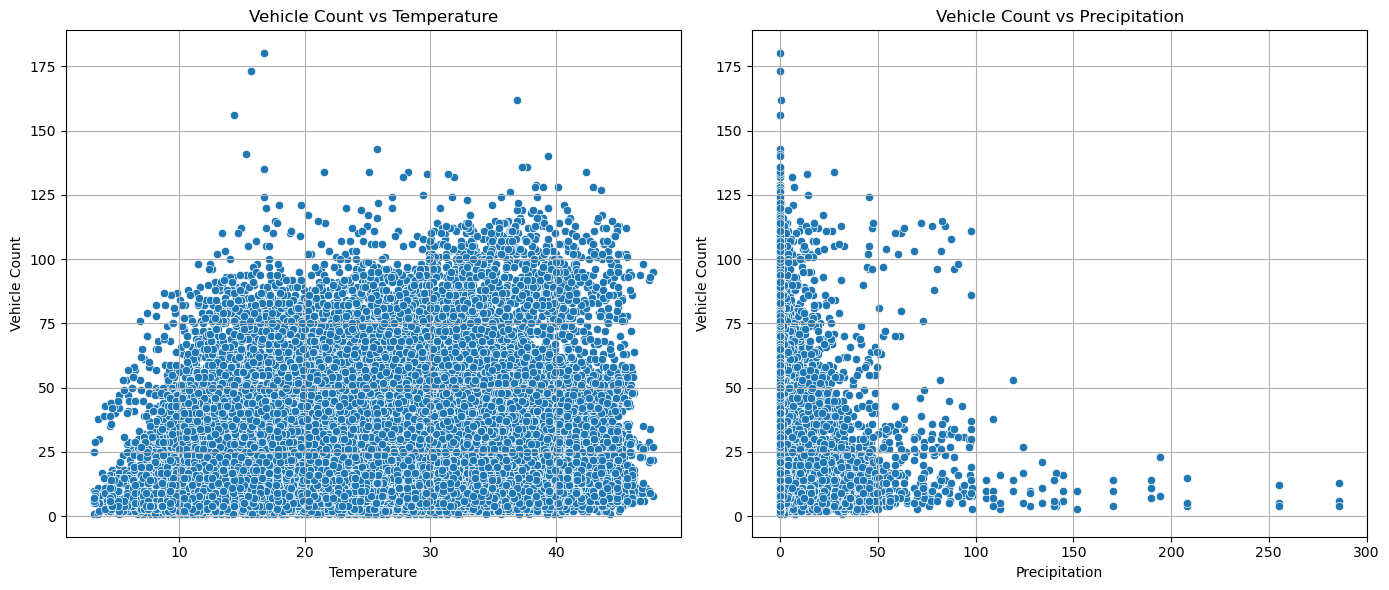

In [202]:
# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot for Vehicles vs Temperature
sns.scatterplot(data=df, x='temperature', y='Vehicles', ax=axs[0])
axs[0].set_title('Vehicle Count vs Temperature')
axs[0].set_xlabel('Temperature')
axs[0].set_ylabel('Vehicle Count')
axs[0].grid()

# Scatter plot for Vehicles vs Precipitation
sns.scatterplot(data=df, x='precipitation', y='Vehicles', ax=axs[1])
axs[1].set_title('Vehicle Count vs Precipitation')
axs[1].set_xlabel('Precipitation')
axs[1].set_ylabel('Vehicle Count')
axs[1].grid()

# Adjust layout
plt.tight_layout()
plt.show()

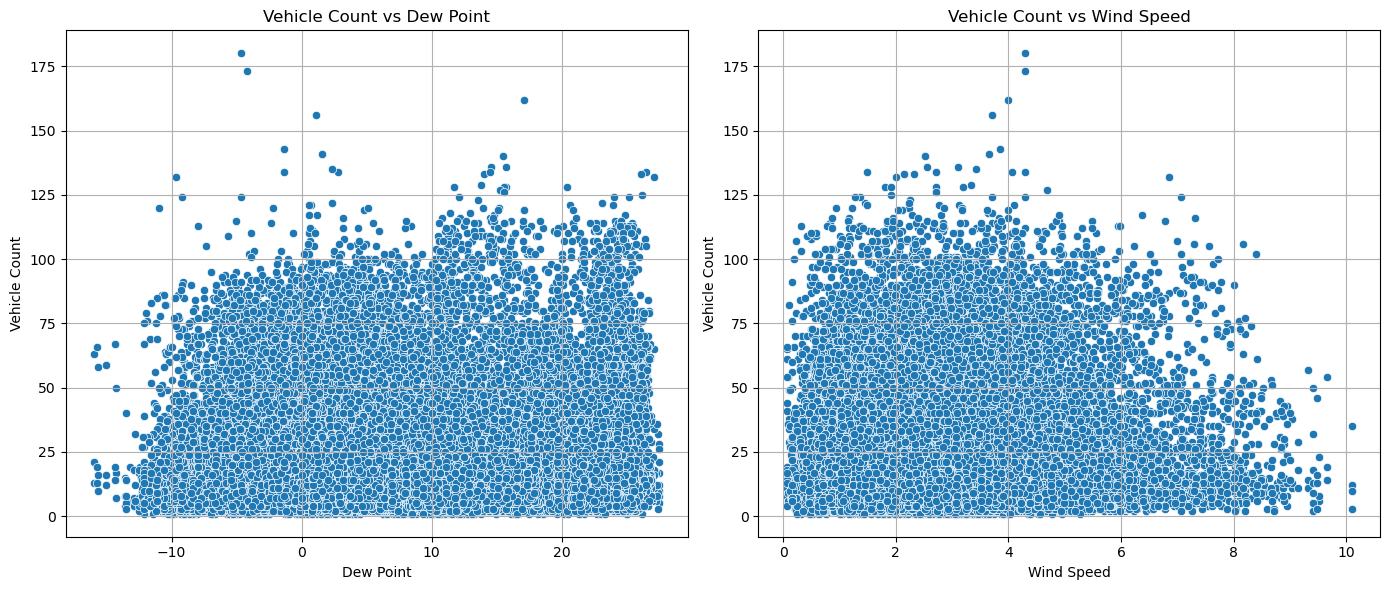

In [200]:
# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot for Vehicles vs Dew Point
sns.scatterplot(data=df, x='dew_point', y='Vehicles', ax=axs[0])
axs[0].set_title('Vehicle Count vs Dew Point')
axs[0].set_xlabel('Dew Point')
axs[0].set_ylabel('Vehicle Count')
axs[0].grid()

# Scatter plot for Vehicles vs Wind Speed
sns.scatterplot(data=df, x='wind_speed', y='Vehicles', ax=axs[1])
axs[1].set_title('Vehicle Count vs Wind Speed')
axs[1].set_xlabel('Wind Speed')
axs[1].set_ylabel('Vehicle Count')
axs[1].grid()

# Adjust layout
plt.tight_layout()
plt.show()

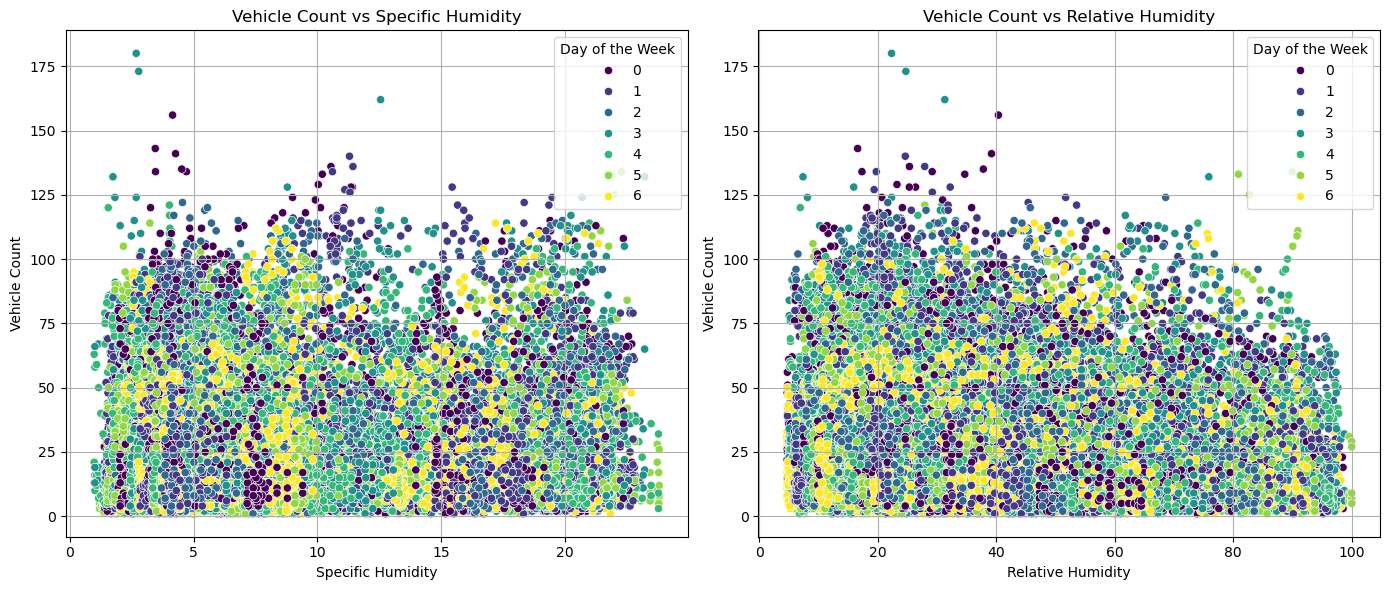

In [206]:
#Create subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot for Vehicles vs Specific Humidity
sns.scatterplot(data=df, x='specific humidity', y='Vehicles', hue='DayOfWeek', palette='viridis', ax=axs[0]) 
axs[0].set_title('Vehicle Count vs Specific Humidity') 
axs[0].set_xlabel('Specific Humidity') 
axs[0].set_ylabel('Vehicle Count') 
axs[0].legend(title='Day of the Week') 
axs[0].grid()

# Scatter plot for Vehicles vs Relative Humidity
sns.scatterplot(data=df, x='relative_humidity', y='Vehicles', hue='DayOfWeek', palette='viridis', ax=axs[1]) 
axs[1].set_title('Vehicle Count vs Relative Humidity') 
axs[1].set_xlabel('Relative Humidity') 
axs[1].set_ylabel('Vehicle Count') 
axs[1].legend(title='Day of the Week') 
axs[1].grid()

# Adjust layout
plt.tight_layout()
plt.show()

In [146]:
# 1. Calculate congestion metrics
# Calculate average vehicle count per hour
avg_vehicles_per_hour = df.groupby(['Hour'])['Vehicles'].mean().reset_index()
avg_vehicles_per_hour.rename(columns={'Vehicles': 'Avg_Vehicles'}, inplace=True)

# Display average vehicles per hour
print("Average Vehicles per Hour:")
print(avg_vehicles_per_hour)

Average Vehicles per Hour:
    Hour  Avg_Vehicles
0      0     23.540648
1      1     19.654863
2      2     17.102743
3      3     14.847382
4      4     12.973067
5      5     12.173566
6      6     12.980050
7      7     14.703242
8      8     16.402993
9      9     19.379551
10    10     24.229925
11    11     27.495262
12    12     28.403990
13    13     25.588529
14    14     27.702743
15    15     27.650374
16    16     26.674314
17    17     26.648379
18    18     28.095262
19    19     29.854863
20    20     29.824938
21    21     28.202993
22    22     27.226933
23    23     25.635411


In [148]:
# 2. Identify peak hours
# Calculate moving average and standard deviation
avg_vehicles_per_hour['Moving_Avg'] = avg_vehicles_per_hour['Avg_Vehicles'].rolling(window=3, min_periods=1).mean()
avg_vehicles_per_hour['Std_Dev'] = avg_vehicles_per_hour['Avg_Vehicles'].rolling(window=3, min_periods=1).std()

# Identify peak hours based on moving average
peak_hours = avg_vehicles_per_hour[avg_vehicles_per_hour['Avg_Vehicles'] == avg_vehicles_per_hour['Avg_Vehicles'].max()]

# Display peak hours
print("\nPeak Hours:")
print(peak_hours)


Peak Hours:
    Hour  Avg_Vehicles  Moving_Avg   Std_Dev
19    19     29.854863   28.199501  1.605781


In [150]:
# 3. Examine temporal patterns
# Average vehicles by Day of the Week
avg_vehicles_by_day = df.groupby(['DayOfWeek'])['Vehicles'].mean().reset_index()
avg_vehicles_by_day.rename(columns={'Vehicles': 'Avg_Vehicles'}, inplace=True)

# Display average vehicles by day of the week
print("\nAverage Vehicles by Day of the Week:")
print(avg_vehicles_by_day)

# Average vehicles by Month
avg_vehicles_by_month = df.groupby(['Month'])['Vehicles'].mean().reset_index()
avg_vehicles_by_month.rename(columns={'Vehicles': 'Avg_Vehicles'}, inplace=True)

# Display average vehicles by month
print("\nAverage Vehicles by Month:")
print(avg_vehicles_by_month)


Average Vehicles by Day of the Week:
   DayOfWeek  Avg_Vehicles
0          0     23.904496
1          1     24.853944
2          2     23.999129
3          3     24.315813
4          4     23.270325
5          5     20.061043
6          6     19.211351

Average Vehicles by Month:
    Month  Avg_Vehicles
0       1     20.824121
1       2     23.312155
2       3     22.886307
3       4     23.475260
4       5     23.594640
5       6     25.372830
6       7     22.744241
7       8     22.099932
8       9     24.897569
9      10     24.827236
10     11     20.642720
11     12     19.752546


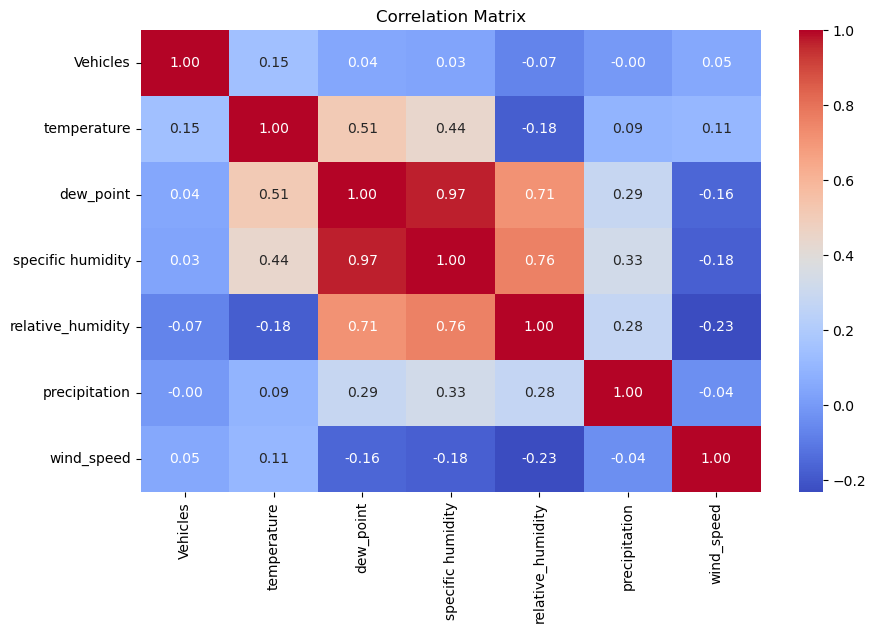

In [160]:
# 4. Analyze influencing factors
# Correlation analysis
correlation_matrix = df[['Vehicles', 'temperature', 'dew_point', 'specific humidity', 'relative_humidity', 'precipitation', 'wind_speed']].corr()

# Visualize correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

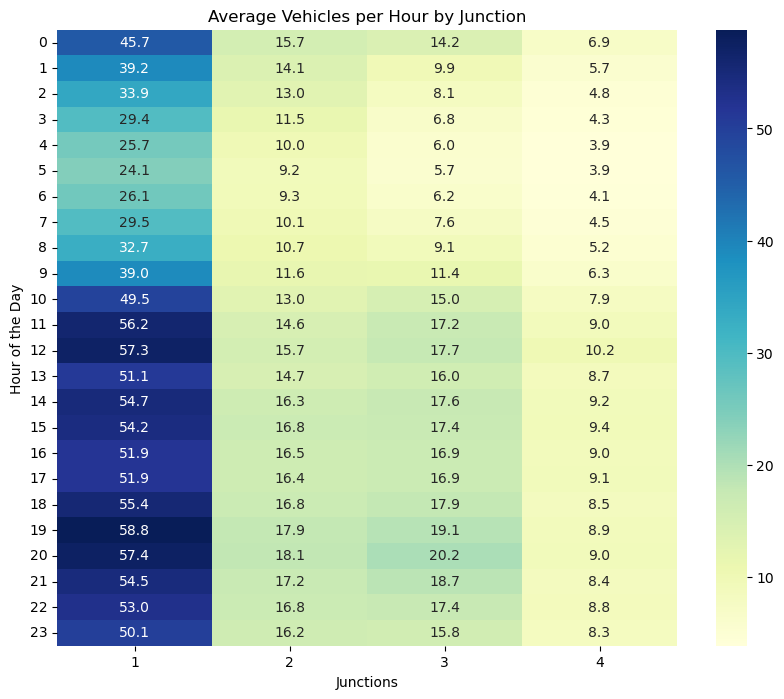

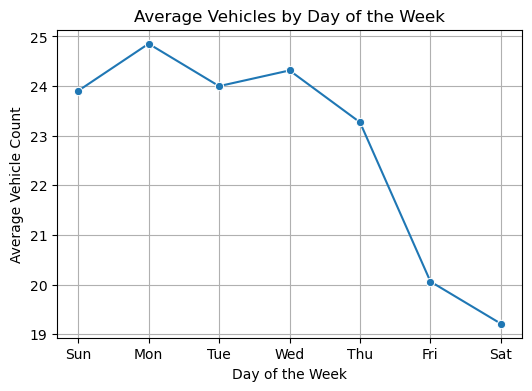

In [194]:
# 1. Create visualizations

# Average vehicles per hour for each junction
avg_vehicles_per_hour = df.groupby(['Hour', 'Junction'])['Vehicles'].mean().unstack()

# Heatmap for average vehicles per hour
plt.figure(figsize=(10, 8))
sns.heatmap(avg_vehicles_per_hour, cmap='YlGnBu', annot=True, fmt=".1f")
plt.title('Average Vehicles per Hour by Junction')
plt.xlabel('Junctions')
plt.ylabel('Hour of the Day')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()

# Line chart for average vehicles by day of the week
avg_vehicles_by_day = df.groupby(['DayOfWeek'])['Vehicles'].mean().reset_index()
plt.figure(figsize=(6, 4))
sns.lineplot(data=avg_vehicles_by_day, x='DayOfWeek', y='Vehicles', marker='o')
plt.title('Average Vehicles by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Vehicle Count')
plt.xticks(ticks=np.arange(0, 7), labels=['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat'])
plt.grid()
plt.show()

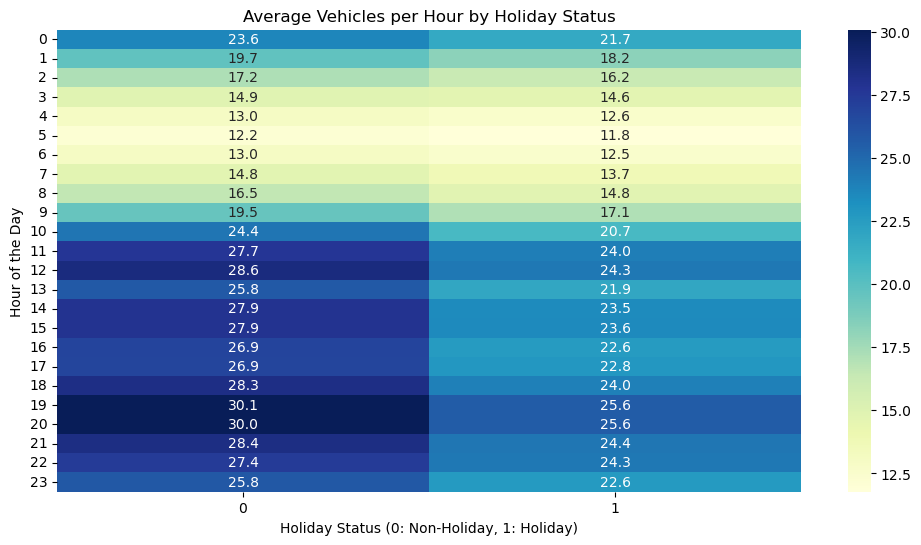

In [198]:
#  Create heatmap for average vehicles per hour by holiday status
avg_vehicles_per_hour = df.groupby(['Hour', 'holiday'])['Vehicles'].mean().unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(avg_vehicles_per_hour, cmap='YlGnBu', annot=True, fmt=".1f")
plt.title('Average Vehicles per Hour by Holiday Status')
plt.xlabel('Holiday Status (0: Non-Holiday, 1: Holiday)')
plt.ylabel('Hour of the Day')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()